# Download Module from Library

In [27]:
# penting execute ini untuk mencegah error di preprocessing
%pip install emoji
%pip install PySastrawi
%pip install numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [28]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ACER\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [29]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ACER\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [30]:
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ACER\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\ACER\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

# Read CSV

In [31]:
# Import Library
import pandas as pd
import matplotlib.pyplot as plt

In [49]:
# Read CSV from sample data
data = pd.read_csv('..\Emodet-App-New-Thesis\dataset\PRDECT-ID.csv')

<>:2: SyntaxWarning: invalid escape sequence '\E'
<>:2: SyntaxWarning: invalid escape sequence '\E'
C:\Users\ACER\AppData\Local\Temp\ipykernel_46040\784381015.py:2: SyntaxWarning: invalid escape sequence '\E'
  data = pd.read_csv('..\Emodet-App-New-Thesis\dataset\PRDECT-ID.csv')
C:\Users\ACER\AppData\Local\Temp\ipykernel_46040\784381015.py:2: SyntaxWarning: invalid escape sequence '\E'
  data = pd.read_csv('..\Emodet-App-New-Thesis\dataset\PRDECT-ID.csv')


FileNotFoundError: [Errno 2] No such file or directory: '..\\Emodet-App-New-Thesis\\dataset\\PRDECT-ID.csv'

# Data Understanding

In [33]:
display(data.head(1))
data.columns

,Category,Product Name,Location,Price,Overall Rating,Number Sold,Total Review,Customer Rating,Customer Review,Sentiment,Emotion
0,Computers and Laptops,Wireless Keyboard i8 Mini TouchPad Mouse 2.4G ...,Jakarta Utara,53500,4.9,5449,2369,5,Alhamdulillah berfungsi dengan baik. Packaging...,Positive,Happy


Index(['Category', 'Product Name', 'Location', 'Price', 'Overall Rating',
       'Number Sold', 'Total Review', 'Customer Rating', 'Customer Review',
       'Sentiment', 'Emotion'],
      dtype='object')

In [34]:
kamus_alay = pd.read_csv('D:\Projects\Emodet-App-New-Thesis\dataset\kamusalay.csv', encoding='ISO-8859-1', header = None)
kamus_alay_dict = kamus_alay.set_index(0).to_dict('dict')[1]

<>:1: SyntaxWarning: invalid escape sequence '\P'
<>:1: SyntaxWarning: invalid escape sequence '\P'
C:\Users\ACER\AppData\Local\Temp\ipykernel_46040\320913540.py:1: SyntaxWarning: invalid escape sequence '\P'
  kamus_alay = pd.read_csv('D:\Projects\Emodet-App-New-Thesis\dataset\kamusalay.csv', encoding='ISO-8859-1', header = None)


# Data Selecting

In [35]:
from collections import Counter
data = pd.DataFrame(data)
data = data[['Customer Review', 'Emotion']]
print(data)
print(data['Emotion'].value_counts())
print(Counter(data['Emotion']))



                                        Customer Review Emotion
0     Alhamdulillah berfungsi dengan baik. Packaging...   Happy
1     barang bagus dan respon cepat, harga bersaing ...   Happy
2     barang bagus, berfungsi dengan baik, seler ram...   Happy
3     bagus sesuai harapan penjual nya juga ramah. t...   Happy
4     Barang Bagus, pengemasan Aman, dapat Berfungsi...   Happy
...                                                 ...     ...
5395  Harga bersaing, barang sesuai pesanan. Saya na...    Love
5396  Beli ini krn Anak & Istri mau liburan di Jakar...    Love
5397  pengemasan barang baik, kondisi barang jg utuh...   Happy
5398  Mungil tapi bekerja dng baik. Dan murahh terja...   Happy
5399  Produk sesuai deskripsi, packing aman terlindu...    Love

[5400 rows x 2 columns]
Emotion
Happy      1770
Sadness    1202
Fear        920
Love        809
Anger       699
Name: count, dtype: int64
Counter({'Happy': 1770, 'Sadness': 1202, 'Fear': 920, 'Love': 809, 'Anger': 699})


# Data Cleaning

## Preprocessing
The second preprocessing step is to convert the data into a format that can be used by the machine learning

### Text Processing

In [36]:
import string
import regex as re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

In [37]:
# pake kamus alay

def process_cleaning(text):

    # remove emoji spesifik, angka, url dulu
    text_cleaning_re = r"rt|url|[^\w\s]|'|nbsp|https\S+|[0-9]+"
    text_sub = re.sub(text_cleaning_re, ' ', str(text))

    # Remove strip / trims
    text_strip = text_sub.strip()

    # remove punctutation/simbolll
    translator = str.maketrans('', '', string.punctuation)
    text_no_punct = text_strip.translate(translator)

    # Lower Case
    text_lower = text_no_punct.casefold()

    # tokenize
    text_token_stan = word_tokenize(text_lower)

    word_dict = []
    for word in text_token_stan:
        word_dict.append(kamus_alay_dict.get(word, word))
    tokens = " ".join(word_dict)

    # tambah kata singkatan =
    more_stopword = ["sih","nya"]

    # menampung stopword ke variabel untuk jadi operator remove stopword
    stopword_user = StopWordRemoverFactory().get_stop_words() + more_stopword
    # stopword_user = StopWordRemoverFactory().get_stop_words()

    # alternatif untuk perbaiki akurasi
    token_new = word_tokenize(tokens)
    filter_new = []
    filter_new2 = [word.strip() for word in token_new]
    filter_new = [word for word in filter_new2 if not word in stopword_user]
    tokens = " ".join(filter_new)

    return tokens

In [38]:
import numpy as np
import string

data['cleaned with dict'] = data['Customer Review'].apply(process_cleaning)

x_cleaned = data['cleaned with dict']

data.head(10)

,Customer Review,Emotion,cleaned with dict
0,Alhamdulillah berfungsi dengan baik. Packaging...,Happy,alhamdulillah berfungsi packaging aman respon ...
1,"barang bagus dan respon cepat, harga bersaing ...",Happy,barang bagus respon cepat harga bersaing
2,"barang bagus, berfungsi dengan baik, seler ram...",Happy,barang bagus berfungsi seler ramah pengiriman ...
3,bagus sesuai harapan penjual nya juga ramah. t...,Happy,bagus sesuai harapan penjual ramah terima kasi...
4,"Barang Bagus, pengemasan Aman, dapat Berfungsi...",Happy,barang bagus pengemasan aman berfungsi
5,"barang bagus, seller ramah..",Happy,barang bagus seller ramah
6,mantap paten joss,Happy,mantap paten joss
7,"Works fine. Respon seller cepat, barang berfun...",Happy,works fine respon seller cepat barang berfungs...
8,barang bagus.. segel.. utuh.. original.. berfu...,Happy,barang bagus segel utuh original berfungsi sel...
9,Barang datang dan berfungsi dengan baik dan te...,Happy,barang berfungsi bagus lampu birunya


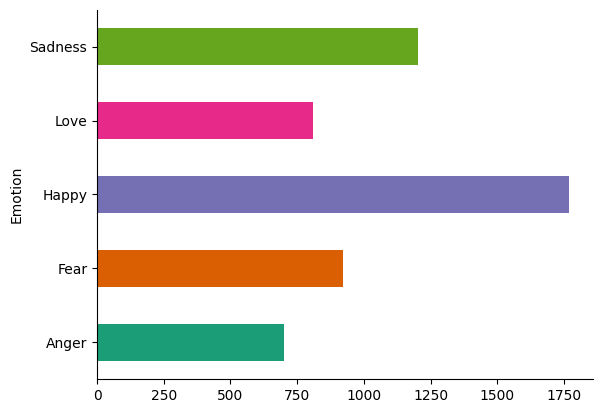

In [39]:
# @title Emotion

from matplotlib import pyplot as plt
import seaborn as sns
data.groupby('Emotion').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

## Data Constructing
Data Transformation -
Data Transformation is the process of converting data from one format to another. This can include data cleaning,

In [40]:
from sklearn.preprocessing import LabelEncoder

In [41]:
print(Counter(data["Emotion"]))
label_encoder = LabelEncoder()
data["emotion"] = label_encoder.fit_transform(data["Emotion"])
print(Counter(data["emotion"]))
y_replaced = data["emotion"]
print(y_replaced)

Counter({'Happy': 1770, 'Sadness': 1202, 'Fear': 920, 'Love': 809, 'Anger': 699})
Counter({2: 1770, 4: 1202, 1: 920, 3: 809, 0: 699})
0       2
1       2
2       2
3       2
4       2
       ..
5395    3
5396    3
5397    2
5398    2
5399    3
Name: emotion, Length: 5400, dtype: int64


# Modeling
## Select model techniques:


### Machine Learning
model_techniques = ['Random Forest', 'Support Vector Machines', 'Naive Bayes', 'Logistic Regression']

In [42]:
from sklearn.linear_model import LogisticRegression

In [43]:
lr = LogisticRegression()
# references:
# https://towardsdatascience.com/how-to-handle-multiclass-imbalanced-data-say-no-to-smote-e9a7f393c310

## Data Mining

### Machine Learning

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import HashingVectorizer
import seaborn as sns

In [45]:
tf_vect = TfidfVectorizer()

x = x_cleaned
y = y_replaced # emotion field
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=225)

In [46]:
model_lr_tf = Pipeline([('vectorizer',tf_vect),('classifier',lr)])
lr = model_lr_tf.fit(x_train, y_train)

In [48]:
import pickle
pickle.dump(lr, open('D:\Projects\Emodet-App-New-Thesis\model\test', 'wb'))

<>:2: SyntaxWarning: invalid escape sequence '\P'
<>:2: SyntaxWarning: invalid escape sequence '\P'
C:\Users\ACER\AppData\Local\Temp\ipykernel_46040\1276935881.py:2: SyntaxWarning: invalid escape sequence '\P'
  pickle.dump(lr, open('D:\Projects\Emodet-App-New-Thesis\model\test', 'wb'))
C:\Users\ACER\AppData\Local\Temp\ipykernel_46040\1276935881.py:2: SyntaxWarning: invalid escape sequence '\P'
  pickle.dump(lr, open('D:\Projects\Emodet-App-New-Thesis\model\test', 'wb'))


OSError: [Errno 22] Invalid argument: 'D:\\Projects\\Emodet-App-New-Thesis\\model\test'